In [ ]:
!kaggle datasets download -d jayaprakashpondy/pancreatic-ct-images
!unzip pancreatic-ct-images.zip -d /content/dataset

Dataset URL: https://www.kaggle.com/datasets/jayaprakashpondy/pancreatic-ct-images
License(s): CC0-1.0
100% 70.1M/70.1M [00:00<00:00, 178MB/s]

Archive:  pancreatic-ct-images.zip
  inflating: /content/dataset/DATASET/test/test/normal/1-001.jpg  
  inflating: /content/dataset/DATASET/test/test/normal/1-002.jpg  
  inflating: /content/dataset/DATASET/test/test/normal/1-003.jpg  
  inflating: /content/dataset/DATASET/test/test/normal/1-004.jpg  
  inflating: /content/dataset/DATASET/test/test/normal/1-005.jpg  
  inflating: /content/dataset/DATASET/test/test/normal/1-006.jpg  
  inflating: /content/dataset/DATASET/test/test/normal/1-007.jpg  
  inflating: /content/dataset/DATASET/test/test/normal/1-008.jpg  
  inflating: /content/dataset/DATASET/test/test/normal/1-009.jpg  
  inflating: /content/dataset/DATASET/test/test/normal/1-010.jpg  
  inflating: /content/dataset/DATASET/test/test/normal/1-011.jpg  
  inflating: /content/dataset/DATASET/test/test/normal/1-012.jpg  
  inflating: /con

In [ ]:
!ls /content/dataset

DATASET


In [ ]:
import os
print(os.listdir('/content/dataset'))

['DATASET']


In [ ]:
import os
import shutil
import random

source = '/content/dataset/DATASET/train/train'
train_dir = '/content/dataset/DATASET/train_new'
val_dir = '/content/dataset/DATASET/val'
shutil.rmtree('/content/dataset/DATASET/train_new', ignore_errors=True)
shutil.rmtree('/content/dataset/DATASET/val', ignore_errors=True)

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

for class_name in os.listdir(source):
    class_path = os.path.join(source, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    split = int(0.8 * len(images))

    train_images = images[:split]
    val_images = images[split:]

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

    for img in train_images:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(train_dir, class_name, img))

    for img in val_images:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(val_dir, class_name, img))

In [ ]:
train_generator = train_datagen.flow_from_directory(
    '/content/dataset/DATASET/train_new',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = val_datagen.flow_from_directory(
    '/content/dataset/DATASET/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 798 images belonging to 2 classes.
Found 201 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras import regularizers

def create_model(optimizer):
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(299, 299, 3)
    )


    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.6)(x)


    output = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
from tensorflow.keras.optimizers import Adam, RMSprop, Adagrad, SGD, Nadam

optimizer_dict = {
    "Adam": lambda: Adam(),
    "RMSprop": lambda: RMSprop(),
    "Adagrad": lambda: Adagrad(),
    "SGD": lambda: SGD(),
    "Nadam": lambda: Nadam(),
}



In [ ]:
history_dict = {}
trained_models = {}

EPOCHS = 10

for name, opt_fn in optimizer_dict.items():
    print(f"\n🔷 Training with {name}")

    train_generator = train_datagen.flow_from_directory(
        '/content/dataset/DATASET/train_new',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )

    validation_generator = val_datagen.flow_from_directory(
        '/content/dataset/DATASET/val',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary'
    )


    optimizer = opt_fn()

    model = create_model(optimizer)

    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        callbacks=[early_stop, reduce_lr],
        epochs=EPOCHS,
        verbose=2
    )

    history_dict[name] = history
    trained_models[name] = model


🔷 Training with Adam
Found 798 images belonging to 2 classes.
Found 201 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
80/80 - 246s - 3s/step - accuracy: 0.9386 - loss: 0.3285 - val_accuracy: 0.9801 - val_loss: 0.1992 - learning_rate: 0.0010
Epoch 2/10
80/80 - 257s - 3s/step - accuracy: 0.9762 - loss: 0.1911 - val_accuracy: 0.9801 - val_loss: 0.1731 - learning_rate: 0.0010
Epoch 3/10
80/80 - 232s - 3s/step - accuracy: 0.9812 - loss: 0.1653 - val_accuracy: 0.9801 - val_loss: 0.1530 - learning_rate: 0.0010
Epoch 4/10
80/80 - 262s - 3s/step - accuracy: 0.9774 - loss: 0.1663 - val_accuracy: 0.9801 - val_loss: 0.1423 - learning_rate: 0.0010
Epoch 5/10
80/80 - 229s - 3s/step - accuracy: 0.9699 - loss: 0.1617 - val_accuracy: 0.9801 - val_loss: 0.1333 - learning_rate: 0.0010
Epoch 6/10
80/80 - 230s - 3s/step - accuracy: 0.9825 - loss: 0.1511 - val_accuracy: 0.9801 - val_loss: 0.1321 - learning_rate: 0.0010
Epoch 7/10
80/80 - 230s - 3s/step - accur

In [ ]:
model.save("adam_model.h5")

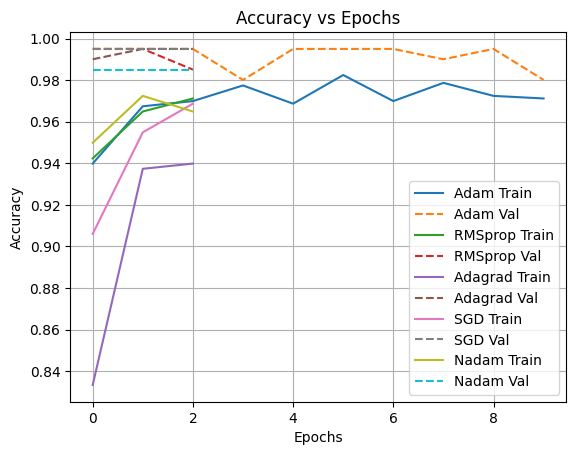

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for name, history in history_dict.items():
    plt.plot(history.history['accuracy'], label=f'{name} Train')
    plt.plot(history.history['val_accuracy'], linestyle='--', label=f'{name} Val')

plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

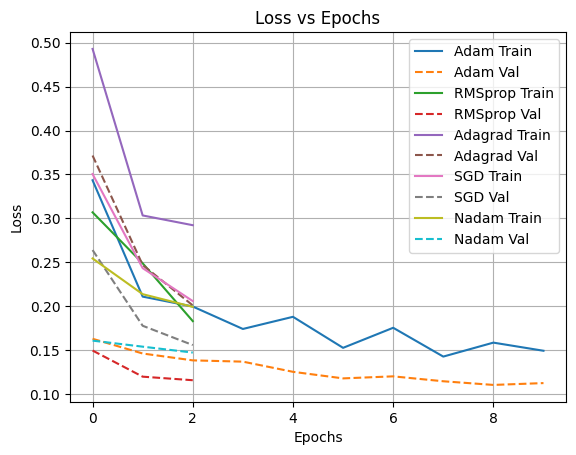

In [ ]:
plt.figure()

for name, history in history_dict.items():
    plt.plot(history.history['loss'], label=f'{name} Train')
    plt.plot(history.history['val_loss'], linestyle='--', label=f'{name} Val')

plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

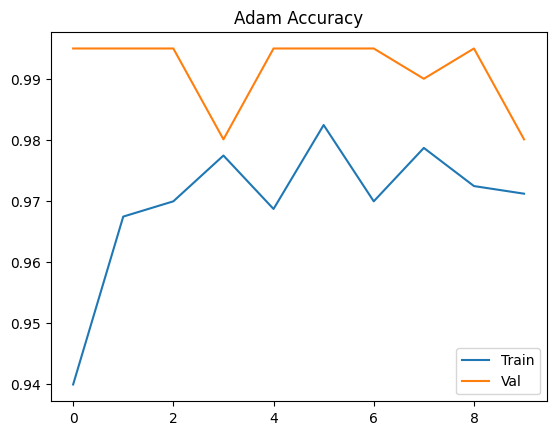

In [ ]:
name = 'Adam'
history = history_dict[name]

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title(f'{name} Accuracy')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

✅ Dataset split done
Found 798 images belonging to 2 classes.
Found 201 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,065,185 (84.17 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/3
25/25 - 136s - 5s/step - accuracy: 0.9336 - loss: 0.1486 - val_accuracy: 0.9751 - val_loss: 0.0830
Epoch 2/3
25/25 - 133s - 5s/step - accuracy: 0.9762 - loss: 0.0626 - val_accuracy: 0.9801 - val_loss: 0.0576
Epoch 3/3
25/25 - 117s - 5s/step - accuracy: 0.9762 - loss: 0.0621 - val_accuracy: 0.9900 - val_loss: 0.0358
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step


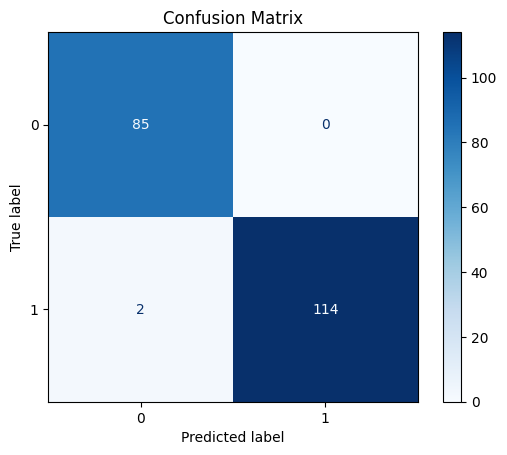


📊 Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        85
           1       1.00      0.98      0.99       116

    accuracy                           0.99       201
   macro avg       0.99      0.99      0.99       201
weighted avg       0.99      0.99      0.99       201

✅ Model saved as final_model.h5


In [ ]:

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

source = '/content/dataset/DATASET/train/train'
train_dir = '/content/dataset/DATASET/train_new'
val_dir = '/content/dataset/DATASET/val'

shutil.rmtree(train_dir, ignore_errors=True)
shutil.rmtree(val_dir, ignore_errors=True)

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

for class_name in os.listdir(source):
    class_path = os.path.join(source, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    split = int(0.8 * len(images))

    train_images = images[:split]
    val_images = images[split:]

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

    for img in train_images:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(train_dir, class_name, img))

    for img in val_images:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(val_dir, class_name, img))

print(" Dataset split done")


IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


EPOCHS = 3

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    verbose=2
)


validation_generator.reset()

y_pred_probs = model.predict(validation_generator)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()
y_true = validation_generator.classes

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


print("\n Classification Report:\n")
print(classification_report(y_true, y_pred))


model.save("final_model.h5")
print(" Model saved as final_model.h5")

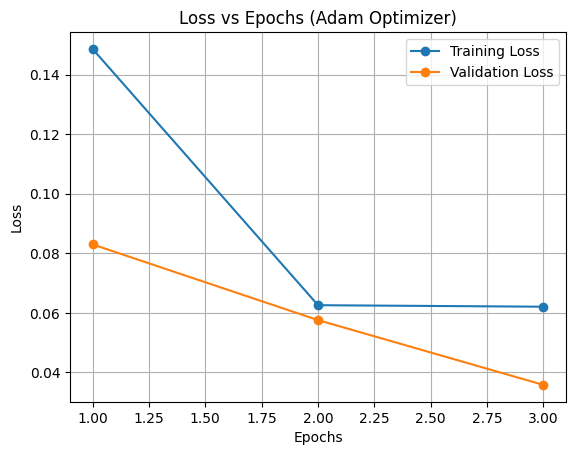

In [ ]:
import matplotlib.pyplot as plt


train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# Plot
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

plt.title('Loss vs Epochs (Adam Optimizer)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()